In [1]:
from SFC_Torch import SFcalculator
import torch

In [2]:
cif_file = '/global/homes/k/kminseo/SFcalculator_torch/tests/data/1dur_nometal_onlyatoms.cif'

In [3]:
# Check if we can extract the necessary arrays from boltz prediction cif file
import gemmi
import numpy as np
structure = gemmi.read_structure(cif_file)
model = structure[0]  # Use the first model

# Collect all Atom objects
atoms = [atom for chain in model for residue in chain for atom in residue]

positions = np.array([[atom.pos.x, atom.pos.y, atom.pos.z] for atom in atoms], dtype=np.float32)
b_factors = np.array([atom.b_iso if hasattr(atom, "b_iso") else atom.occ for atom in atoms], dtype=np.float32)
occupancies = np.array([atom.occ for atom in atoms], dtype=np.float32)
aniso_b = np.zeros((len(atoms), 3, 3), dtype=np.float32)

print(positions.shape)   # Positions: [N_atoms, 3]
print(b_factors.shape)   # Isotropic B-factors: [N_atoms,]
print(occupancies.shape) # Occupancy: [N_atoms,]
print(aniso_b.shape)     # Anisotropic B-matrix (optional, set zeros): [N_atoms, 3, 3]

(379, 3)
(379,)
(379,)
(379, 3, 3)


In [22]:
import os
import gemmi

# Check what's in CIF file
structure = gemmi.read_structure(cif_file)
print("Space group:", structure.spacegroup_hm)
print("Unit cell:", structure.cell)
print("Number of atoms:", len(structure[0]))

# Check unit cell parameters
cell = structure.cell
print(f"Unit cell: a={cell.a:.2f}, b={cell.b:.2f}, c={cell.c:.2f}")
print(f"Angles: α={cell.alpha:.2f}, β={cell.beta:.2f}, γ={cell.gamma:.2f}")

print("CIF file exists:", os.path.exists(cif_file))
print("CIF file path:", cif_file)

try:
    structure = gemmi.read_structure(cif_file)
    print("CIF file loaded successfully")
    print("Number of models:", len(structure))
    if len(structure) > 0:
        print("Number of chains:", len(structure[0]))
except Exception as e:
    print("Error reading CIF file:", e)

# Extract dmin (highest resolution) if available
doc = gemmi.cif.read(cif_file)
block = doc.sole_block()

# Try common tags where dmin (highest resolution) is stored
dmin_tags = [
    '_refine.ls_d_res_high',    # common in mmCIF
    '_reflns.d_resolution_high' # common in small-molecule CIF
]
dmin = None

for tag in dmin_tags:
    dmin_str = block.find_value(tag)
    if dmin_str:
        dmin = float(dmin_str)
        print(f"Highest resolution (d_min) reported in CIF: {dmin:.3f} Å")
        break

if not dmin:
    print("No resolution limit found in CIF tags.")


Space group: P 21 21 21
Unit cell: <gemmi.UnitCell(30.52, 37.75, 39.37, 90, 90, 90)>
Number of atoms: 1
Unit cell: a=30.52, b=37.75, c=39.37
Angles: α=90.00, β=90.00, γ=90.00
CIF file exists: True
CIF file path: /global/homes/k/kminseo/SFcalculator_torch/tests/data/1dur_nometal_onlyatoms.cif
CIF file loaded successfully
Number of models: 1
Number of chains: 1
Highest resolution (d_min) reported in CIF: 2.000 Å


In [23]:
sfcalculator = SFcalculator(
    pdbmodel=cif_file,
    mtzdata=None,
    set_experiment=False,
    dmin=2.5
)

In [24]:
print("N_atoms: ", sfcalculator.n_atoms)

N_atoms:  379


In [25]:
biso_np = np.loadtxt('atoms_biso_random.csv', dtype=np.float32)
atoms_biso_tensor = torch.from_numpy(biso_np).to(torch.device('cuda'))
coords_np = np.loadtxt('atoms_random_coords.csv', delimiter=",", dtype=np.float32)
atoms_position_tensor = torch.from_numpy(coords_np).to(torch.device('cuda'))
print(atoms_biso_tensor.device)

# sfcalculator.calc_fprotein(atoms_position_tensor=None, atoms_biso_tensor=atoms_biso_tensor, atoms_occ_tensor=None, atoms_aniso_uw_tensor=None)
# sfcalculator.calc_fprotein(atoms_position_tensor=atoms_position_tensor, atoms_biso_tensor=None, atoms_occ_tensor=None, atoms_aniso_uw_tensor=None)
sfcalculator.calc_fprotein(atoms_position_tensor=None, atoms_biso_tensor=None, atoms_occ_tensor=None, atoms_aniso_uw_tensor=None)
# sfcalculator.calc_fprotein(atoms_position_tensor=None, atoms_biso_tensor=torch.from_numpy(residue_b_factors).to(torch.device('cuda')), atoms_occ_tensor=None, atoms_aniso_uw_tensor=None)

cuda:0


In [26]:
print(torch.abs(sfcalculator.Fprotein_asu).shape)
fprotein_flat = sfcalculator.Fprotein_asu.cpu().detach().numpy().flatten()
print(fprotein_flat)
np.savetxt("Fprotein_gt.csv", fprotein_flat, delimiter="\n")

torch.Size([1747])
[  65.97267 +7.38995004e-05j -258.9404  +2.06750556e-04j
  221.27133 -4.87702710e-05j ...  -97.33542 -1.95621251e-04j
   64.33163 -2.48953896e+01j  -31.061787+1.04013824e+02j]


In [27]:
sfcalculator.atom_pos_orth # ground truth atom coordinates

tensor([[17.0660, -1.7470, 15.6770],
        [18.5110, -1.4160, 15.6320],
        [18.7000, -0.0920, 14.9230],
        ...,
        [13.6840,  4.5230,  7.6190],
        [15.5510,  4.7250,  6.4680],
        [12.4760,  0.3870,  7.7460]], device='cuda:0')

In [28]:
sfcalculator.atom_b_iso

tensor([ 6.9800,  6.8400,  7.1800,  7.4200,  7.8900,  6.5000,  6.8000,  7.0800,
         7.2700,  6.7500,  7.8400,  8.3300,  8.1400,  7.6800,  8.3700,  8.1800,
        10.5200,  6.0200,  6.7300,  7.2300,  7.1100,  6.5100,  6.1900,  7.2900,
         7.3700,  6.1700,  7.6100,  7.4600,  5.4800,  6.0000,  5.1400,  5.2800,
         8.3100,  9.2300,  9.1600,  8.6100,  7.5200, 10.1800, 10.1200, 11.8100,
         9.5300, 12.0900, 12.2000, 12.7000, 12.3400, 14.5200, 15.7900, 17.3700,
        12.2100, 12.0700, 10.5900, 10.6800, 13.2900, 17.9100,  8.9400,  8.1700,
         8.2400,  9.4900,  6.3200,  5.7000,  7.9400,  8.5400,  8.9100,  8.5500,
         8.8700,  8.6300, 10.3900,  8.7000,  8.9800,  9.0000,  9.9300, 10.4300,
         6.8500, 10.8000, 11.7800, 11.2800, 13.1100, 10.0800, 13.2500, 11.8700,
        10.7800, 10.9000, 11.2400, 10.1300,  9.2100,  9.3900, 10.4100, 10.3400,
         7.8900,  8.0500,  7.9000,  7.9400,  8.3800,  6.5000,  8.7800, 10.9700,
        12.2500, 11.8200, 11.8700, 14.90

In [13]:
# convert per-atom ground truth B factors to per-residue averages

import gemmi
import numpy as np
from collections import defaultdict

def get_atom_residue_mapping(cif_file_path):
    """
    Read CIF file and map each atom to its residue sequence ID
    Returns mapping and residue sequence IDs for ATOM records only
    """
    try:
        structure = gemmi.read_structure(cif_file_path)
        atom_to_residue = {}
        atom_index = 0
        
        # Standard amino acid three-letter codes
        standard_aa = {
            'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
            'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL'
        }
        
        for model in structure:
            for chain in model:
                for residue in chain:
                    residue_name = residue.name.strip()
                    
                    # Check if this is a protein residue (ATOM records)
                    if residue_name in standard_aa:
                        residue_seq_id = residue.seqid.num  # This is the sequence ID
                        chain_id = chain.name
                        
                        # Create unique residue identifier
                        residue_key = f"{chain_id}_{residue_seq_id}"
                        
                        # Map each atom in this residue to the residue key
                        for atom in residue:
                            atom_to_residue[atom_index] = {
                                'residue_key': residue_key,
                                'seq_id': residue_seq_id,
                                'chain_id': chain_id,
                                'residue_name': residue_name,
                                'atom_name': atom.name
                            }
                            atom_index += 1
                    else:
                        # Still count non-protein atoms to maintain correct indexing
                        for atom in residue:
                            atom_index += 1
        
        return atom_to_residue
        
    except Exception as e:
        print(f"Error reading CIF file: {e}")
        return None

def convert_atom_to_residue_b_factors_exact(atom_b_iso, cif_file_path):
    """
    Convert per-atom B factors to per-residue averaged B factors using exact residue mapping
    
    Parameters:
    atom_b_iso: array of per-atom B factors from sfcalculator.atom_b_iso
    cif_file_path: path to CIF file to read residue information
    
    Returns:
    residue_b_factors: array of same length as atom_b_iso with averaged B factors per actual residue
    """
    
    # Get atom to residue mapping
    print("Reading CIF file and mapping atoms to residues...")
    atom_to_residue = get_atom_residue_mapping(cif_file_path)
    
    if atom_to_residue is None:
        print("Failed to read CIF file")
        return None
    
    # Group atoms by residue
    residue_groups = defaultdict(list)
    
    for atom_idx, b_factor in enumerate(atom_b_iso):
        if atom_idx in atom_to_residue:
            residue_key = atom_to_residue[atom_idx]['residue_key']
            residue_groups[residue_key].append((atom_idx, b_factor))
    
    print(f"Found {len(residue_groups)} unique protein residues")
    print(f"Atoms per residue: min={min(len(atoms) for atoms in residue_groups.values())}, "
          f"max={max(len(atoms) for atoms in residue_groups.values())}, "
          f"avg={np.mean([len(atoms) for atoms in residue_groups.values()]):.1f}")
    
    # Create output array same length as input
    residue_b_factors = np.copy(atom_b_iso)
    
    # Calculate average B factor for each residue and assign to all atoms in that residue
    for residue_key, atom_list in residue_groups.items():
        # Extract B factors for this residue
        residue_b_values = [b_factor for atom_idx, b_factor in atom_list]
        avg_b_factor = np.mean(residue_b_values)
        
        # Assign average to all atoms in this residue
        for atom_idx, _ in atom_list:
            residue_b_factors[atom_idx] = avg_b_factor
    
    print(f"Converted {len(atom_b_iso)} atom B factors using actual residue groupings")
    return residue_b_factors

# # Complete usage:
# num_residues = get_num_residues_simple(cif_file)
# print(f"Found {num_residues} protein residues")

# Convert atom B factors to residue-averaged B factors (same length as input)
atom_b_iso_cpu = sfcalculator.atom_b_iso.cpu().numpy()
residue_b_factors = convert_atom_to_residue_b_factors_exact(atom_b_iso_cpu, cif_file)

print(f"Input length: {len(atom_b_iso_cpu)}")
print(f"Output length: {len(residue_b_factors)}")
print(f"Same length: {len(atom_b_iso_cpu) == len(residue_b_factors)}")

residue_b_factors

Reading CIF file and mapping atoms to residues...
Found 55 unique protein residues
Atoms per residue: min=4, max=12, avg=6.9
Converted 379 atom B factors using actual residue groupings
Input length: 379
Output length: 379
Same length: True


array([ 7.262    ,  7.262    ,  7.262    ,  7.262    ,  7.262    ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  6.725714 ,  6.725714 ,  6.725714 ,
        6.725714 ,  6.725714 ,  6.725714 ,  6.725714 ,  6.3137503,
        6.3137503,  6.3137503,  6.3137503,  6.3137503,  6.3137503,
        6.3137503,  6.3137503,  9.3675   ,  9.3675   ,  9.3675   ,
        9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,
       13.317499 , 13.317499 , 13.317499 , 13.317499 , 13.317499 ,
       13.317499 , 13.317499 , 13.317499 , 12.791667 , 12.791667 ,
       12.791667 , 12.791667 , 12.791667 , 12.791667 ,  7.81     ,
        7.81     ,  7.81     ,  7.81     ,  7.81     ,  7.81     ,
        8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,
        8.81625  ,  8.81625  ,  8.81625  ,  9.038    ,  9.038    ,
        9.038    ,  9.038    ,  9.038    , 11.716667 , 11.7166

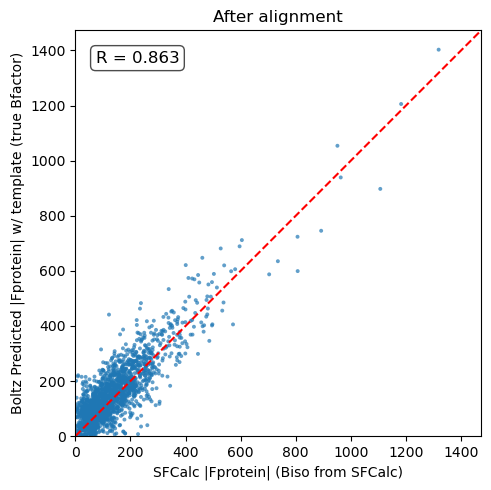

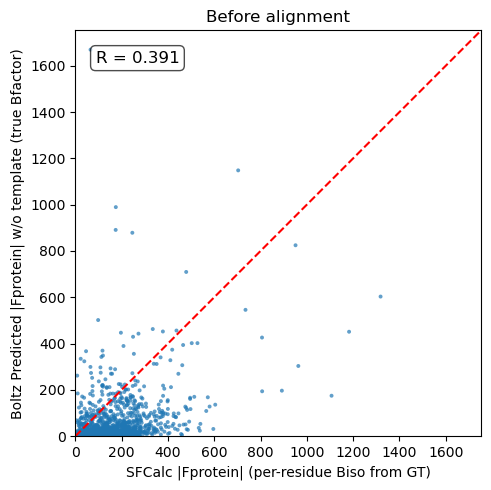

In [29]:
# plot the correlation between the Fprotein_cif and Fprotein_my_pred

from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def amplitudes_from_txt(fname):
    F = np.loadtxt(fname, dtype=complex)
    return np.abs(F)          # |F|

F_cif   = amplitudes_from_txt("Fprotein_gt.csv")
# F_pred  = amplitudes_from_txt("Fprotein_my_pred.csv")
F_pred  = amplitudes_from_txt("Fprotein_my_pred_true_Bfactor.csv")
F_pred_no_align  = amplitudes_from_txt("Fprotein_my_pred_no_align.csv")

n = min(len(F_cif), len(F_pred))
F_cif, F_pred = F_cif[:n], F_pred[:n]

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (Biso from SFCalc)")
plt.ylabel("Boltz Predicted |Fprotein| w/ template (true Bfactor)")
plt.title("After alignment")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred_no_align, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred_no_align.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (per-residue Biso from GT)")
plt.ylabel("Boltz Predicted |Fprotein| w/o template (true Bfactor)")
plt.title("Before alignment")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred_no_align)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

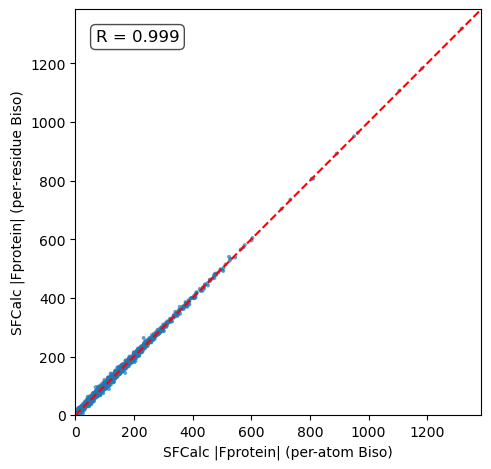

In [15]:
# SFCalc per-residue vs. per-atom 

F_cif   = amplitudes_from_txt("Fprotein_cif_per_residue_B.csv")
F_pred  = amplitudes_from_txt("Fprotein_cif_per_atom_B.csv")

n = min(len(F_cif), len(F_pred))
F_cif, F_pred = F_cif[:n], F_pred[:n]

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (per-atom Biso)")
plt.ylabel("SFCalc |Fprotein| (per-residue Biso)")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

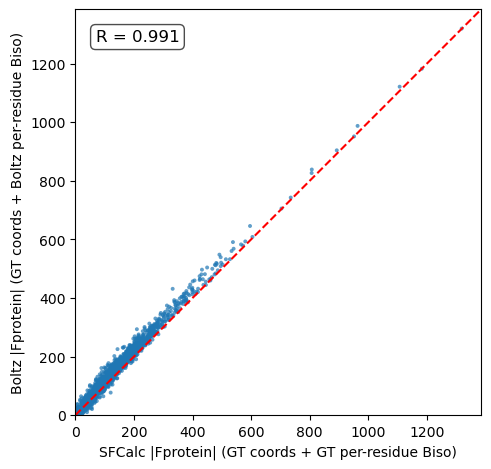

In [16]:
# importance of bfactors and atom coordinates on Fprotein

F_cif   = amplitudes_from_txt("Fprotein_gt.csv")
F_pred  = amplitudes_from_txt("Fprotein_boltz_bfactor.csv")

n = min(len(F_cif), len(F_pred))
F_cif, F_pred = F_cif[:n], F_pred[:n]

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (GT coords + GT per-residue Biso)")
plt.ylabel("Boltz |Fprotein| (GT coords + Boltz per-residue Biso)")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

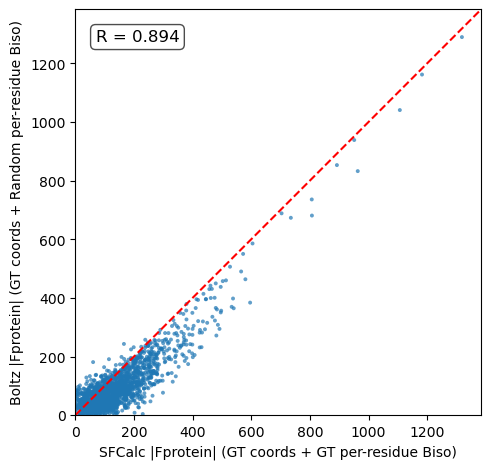

In [17]:
F_cif   = amplitudes_from_txt("Fprotein_gt.csv")
F_pred  = amplitudes_from_txt("Fprotein_random_bfactor.csv")

n = min(len(F_cif), len(F_pred))
F_cif, F_pred = F_cif[:n], F_pred[:n]

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (GT coords + GT per-residue Biso)")
plt.ylabel("Boltz |Fprotein| (GT coords + Random per-residue Biso)")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

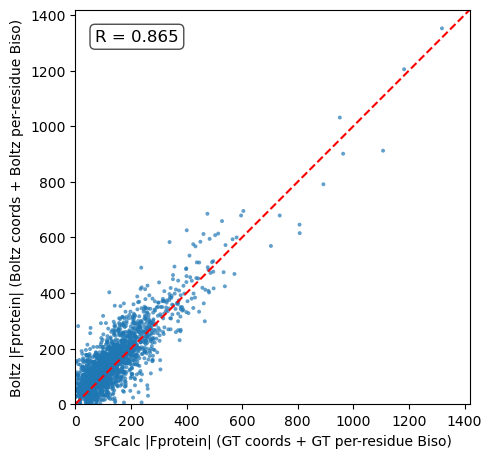

In [18]:

F_cif   = amplitudes_from_txt("Fprotein_gt.csv")
F_pred  = amplitudes_from_txt("Fprotein_before_exp_guid_boltz_coords_boltz_bfactor.csv")

n = min(len(F_cif), len(F_pred))
F_cif, F_pred = F_cif[:n], F_pred[:n]

plt.figure(figsize=(5,5))
plt.scatter(F_cif, F_pred, s=8, alpha=0.7, edgecolor='none')
lims = [0, max(F_cif.max(), F_pred.max()) * 1.05]

plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("SFCalc |Fprotein| (GT coords + GT per-residue Biso)")
plt.ylabel("Boltz |Fprotein| (Boltz coords + Boltz per-residue Biso)")
plt.gca().set_aspect('equal', adjustable='box')

# place the R-factor on the plot
r, _ = pearsonr(F_cif, F_pred)

plt.text(0.05, 0.95,
         f'R = {r:.3f}',
         transform=plt.gca().transAxes,
         ha='left', va='top',
         fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [18]:
# convert per-atom ground truth B factors to per-residue averages

import gemmi
import numpy as np
from collections import defaultdict

def get_atom_residue_mapping(cif_file_path):
    """
    Read CIF file and map each atom to its residue sequence ID
    Returns mapping and residue sequence IDs for ATOM records only
    """
    try:
        structure = gemmi.read_structure(cif_file_path)
        atom_to_residue = {}
        atom_index = 0
        
        # Standard amino acid three-letter codes
        standard_aa = {
            'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
            'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL'
        }
        
        for model in structure:
            for chain in model:
                for residue in chain:
                    residue_name = residue.name.strip()
                    
                    # Check if this is a protein residue (ATOM records)
                    if residue_name in standard_aa:
                        residue_seq_id = residue.seqid.num  # This is the sequence ID
                        chain_id = chain.name
                        
                        # Create unique residue identifier
                        residue_key = f"{chain_id}_{residue_seq_id}"
                        
                        # Map each atom in this residue to the residue key
                        for atom in residue:
                            atom_to_residue[atom_index] = {
                                'residue_key': residue_key,
                                'seq_id': residue_seq_id,
                                'chain_id': chain_id,
                                'residue_name': residue_name,
                                'atom_name': atom.name
                            }
                            atom_index += 1
                    else:
                        # Still count non-protein atoms to maintain correct indexing
                        for atom in residue:
                            atom_index += 1
        
        return atom_to_residue
        
    except Exception as e:
        print(f"Error reading CIF file: {e}")
        return None

def convert_atom_to_residue_b_factors_exact(atom_b_iso, cif_file_path):
    """
    Convert per-atom B factors to per-residue averaged B factors using exact residue mapping
    
    Parameters:
    atom_b_iso: array of per-atom B factors from sfcalculator.atom_b_iso
    cif_file_path: path to CIF file to read residue information
    
    Returns:
    residue_b_factors: array of same length as atom_b_iso with averaged B factors per actual residue
    """
    
    # Get atom to residue mapping
    print("Reading CIF file and mapping atoms to residues...")
    atom_to_residue = get_atom_residue_mapping(cif_file_path)
    
    if atom_to_residue is None:
        print("Failed to read CIF file")
        return None
    
    # Group atoms by residue
    residue_groups = defaultdict(list)
    
    for atom_idx, b_factor in enumerate(atom_b_iso):
        if atom_idx in atom_to_residue:
            residue_key = atom_to_residue[atom_idx]['residue_key']
            residue_groups[residue_key].append((atom_idx, b_factor))
    
    print(f"Found {len(residue_groups)} unique protein residues")
    print(f"Atoms per residue: min={min(len(atoms) for atoms in residue_groups.values())}, "
          f"max={max(len(atoms) for atoms in residue_groups.values())}, "
          f"avg={np.mean([len(atoms) for atoms in residue_groups.values()]):.1f}")
    
    # Create output array same length as input
    residue_b_factors = np.copy(atom_b_iso)
    
    # Calculate average B factor for each residue and assign to all atoms in that residue
    for residue_key, atom_list in residue_groups.items():
        # Extract B factors for this residue
        residue_b_values = [b_factor for atom_idx, b_factor in atom_list]
        avg_b_factor = np.mean(residue_b_values)
        
        # Assign average to all atoms in this residue
        for atom_idx, _ in atom_list:
            residue_b_factors[atom_idx] = avg_b_factor
    
    print(f"Converted {len(atom_b_iso)} atom B factors using actual residue groupings")
    return residue_b_factors

# # Complete usage:
# num_residues = get_num_residues_simple(cif_file)
# print(f"Found {num_residues} protein residues")

# Convert atom B factors to residue-averaged B factors (same length as input)
atom_b_iso_cpu = sfcalculator.atom_b_iso.cpu().numpy()
residue_b_factors = convert_atom_to_residue_b_factors_exact(atom_b_iso_cpu, cif_file)

print(f"Input length: {len(atom_b_iso_cpu)}")
print(f"Output length: {len(residue_b_factors)}")
print(f"Same length: {len(atom_b_iso_cpu) == len(residue_b_factors)}")


Reading CIF file and mapping atoms to residues...
Found 55 unique protein residues
Atoms per residue: min=4, max=12, avg=6.9
Converted 379 atom B factors using actual residue groupings
Input length: 379
Output length: 379
Same length: True


In [19]:
residue_b_factors

array([ 7.262    ,  7.262    ,  7.262    ,  7.262    ,  7.262    ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  6.725714 ,  6.725714 ,  6.725714 ,
        6.725714 ,  6.725714 ,  6.725714 ,  6.725714 ,  6.3137503,
        6.3137503,  6.3137503,  6.3137503,  6.3137503,  6.3137503,
        6.3137503,  6.3137503,  9.3675   ,  9.3675   ,  9.3675   ,
        9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,
       13.317499 , 13.317499 , 13.317499 , 13.317499 , 13.317499 ,
       13.317499 , 13.317499 , 13.317499 , 12.791667 , 12.791667 ,
       12.791667 , 12.791667 , 12.791667 , 12.791667 ,  7.81     ,
        7.81     ,  7.81     ,  7.81     ,  7.81     ,  7.81     ,
        8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,
        8.81625  ,  8.81625  ,  8.81625  ,  9.038    ,  9.038    ,
        9.038    ,  9.038    ,  9.038    , 11.716667 , 11.7166

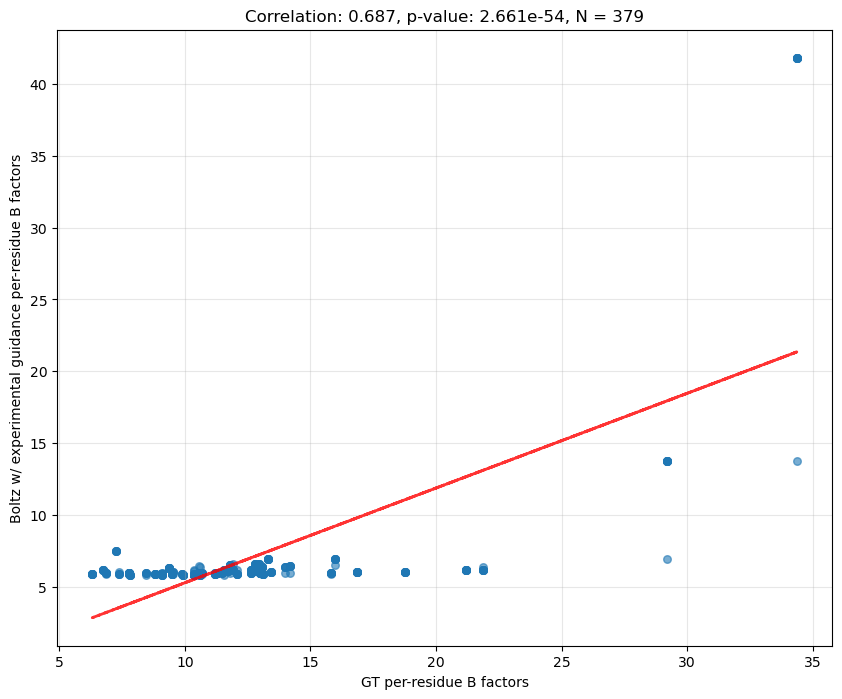

Correlation: 0.6873, p-value: 2.6608e-54


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# csv_file_path = "atoms_biso.csv"
csv_file_path = "atoms_biso_exp_guid.csv"
csv_b_factors = pd.read_csv(csv_file_path, header=None).iloc[:, 0].values

# Get sfcalculator B factors
sfcalc_b_factors = residue_b_factors

# Match lengths
min_length = min(len(sfcalc_b_factors), len(csv_b_factors))
sfcalc_b_factors = sfcalc_b_factors[:min_length]
csv_b_factors = csv_b_factors[:min_length]

# Calculate correlation
correlation, p_value = stats.pearsonr(sfcalc_b_factors, csv_b_factors)

# Create plot
plt.figure(figsize=(10, 8))
plt.scatter(sfcalc_b_factors, csv_b_factors, alpha=0.6, s=30)

# Trend line
z = np.polyfit(sfcalc_b_factors, csv_b_factors, 1)
p = np.poly1d(z)
plt.plot(sfcalc_b_factors, p(sfcalc_b_factors), "r--", alpha=0.8, linewidth=2)

plt.xlabel('GT per-residue B factors')
# plt.ylabel('Boltz per-residue B factors')
plt.ylabel('Boltz w/ experimental guidance per-residue B factors')
plt.title(f'Correlation: {correlation:.3f}, p-value: {p_value:.3e}, N = {min_length}')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correlation: {correlation:.4f}, p-value: {p_value:.4e}")


In [19]:
csv_b_factors

array([ 7.48738432,  7.48738432,  7.48738432,  7.48738432,  7.48738432,
        5.97043324,  5.97043324,  5.97043324,  5.97043324,  5.97043324,
        5.97043324,  5.97043324,  5.97043324,  5.97043324,  5.97043324,
        5.97043324,  5.97043324,  6.15472031,  6.15472031,  6.15472031,
        6.15472031,  6.15472031,  6.15472031,  6.15472031,  5.90393829,
        5.90393829,  5.90393829,  5.90393829,  5.90393829,  5.90393829,
        5.90393829,  5.90393829,  6.35485649,  6.35485649,  6.35485649,
        6.35485649,  6.35485649,  6.35485649,  6.35485649,  6.35485649,
        6.98398304,  6.98398304,  6.98398304,  6.98398304,  6.98398304,
        6.98398304,  6.98398304,  6.98398304,  6.61420202,  6.61420202,
        6.61420202,  6.61420202,  6.61420202,  6.61420202,  5.84285641,
        5.84285641,  5.84285641,  5.84285641,  5.84285641,  5.84285641,
        5.91338825,  5.91338825,  5.91338825,  5.91338825,  5.91338825,
        5.91338825,  5.91338825,  5.91338825,  5.93234062,  5.93

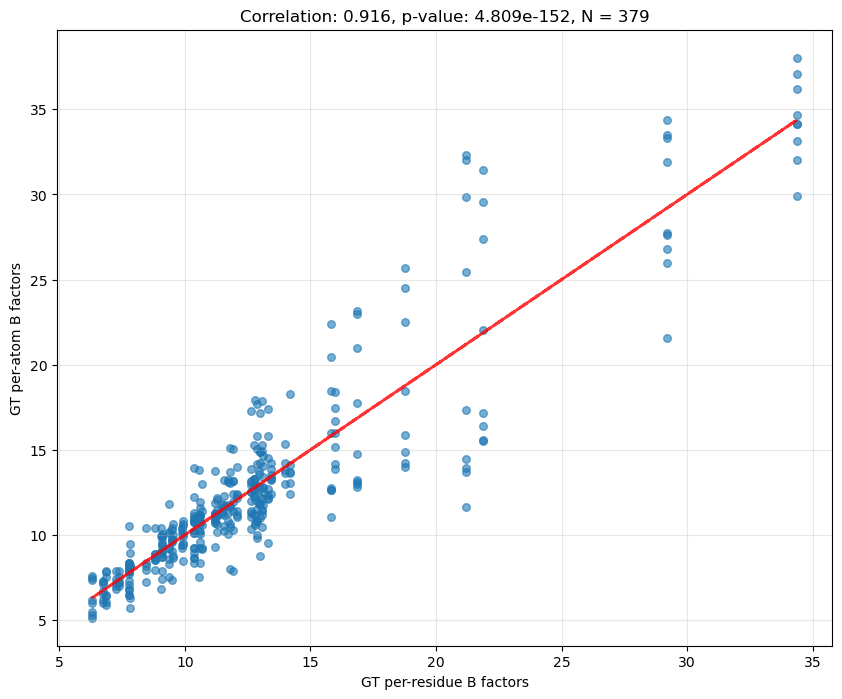

Correlation: 0.9165, p-value: 4.8086e-152


In [40]:
# Calculate correlation
correlation, p_value = stats.pearsonr(residue_b_factors, atom_b_iso_cpu)

# Create plot
plt.figure(figsize=(10, 8))
plt.scatter(residue_b_factors, atom_b_iso_cpu, alpha=0.6, s=30)

# Trend line
z = np.polyfit(residue_b_factors, atom_b_iso_cpu, 1)
p = np.poly1d(z)
plt.plot(residue_b_factors, p(residue_b_factors), "r--", alpha=0.8, linewidth=2)

plt.xlabel('GT per-residue B factors')
plt.ylabel('GT per-atom B factors')
plt.title(f'Correlation: {correlation:.3f}, p-value: {p_value:.3e}, N = {min_length}')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correlation: {correlation:.4f}, p-value: {p_value:.4e}")


In [41]:
atom_b_iso_cpu

array([ 6.98,  6.84,  7.18,  7.42,  7.89,  6.5 ,  6.8 ,  7.08,  7.27,
        6.75,  7.84,  8.33,  8.14,  7.68,  8.37,  8.18, 10.52,  6.02,
        6.73,  7.23,  7.11,  6.51,  6.19,  7.29,  7.37,  6.17,  7.61,
        7.46,  5.48,  6.  ,  5.14,  5.28,  8.31,  9.23,  9.16,  8.61,
        7.52, 10.18, 10.12, 11.81,  9.53, 12.09, 12.2 , 12.7 , 12.34,
       14.52, 15.79, 17.37, 12.21, 12.07, 10.59, 10.68, 13.29, 17.91,
        8.94,  8.17,  8.24,  9.49,  6.32,  5.7 ,  7.94,  8.54,  8.91,
        8.55,  8.87,  8.63, 10.39,  8.7 ,  8.98,  9.  ,  9.93, 10.43,
        6.85, 10.8 , 11.78, 11.28, 13.11, 10.08, 13.25, 11.87, 10.78,
       10.9 , 11.24, 10.13,  9.21,  9.39, 10.41, 10.34,  7.89,  8.05,
        7.9 ,  7.94,  8.38,  6.5 ,  8.78, 10.97, 12.25, 11.82, 11.87,
       14.9 , 14.2 , 14.9 , 17.17, 12.43, 13.25, 13.29, 13.9 , 14.21,
       13.55, 13.35, 12.84, 13.22, 13.12, 12.99, 14.75, 17.77, 20.99,
       22.95, 23.16, 11.94, 10.65, 11.61, 11.13, 10.05,  8.33, 11.22,
       11.48, 12.19,

In [42]:
residue_b_factors

array([ 7.262    ,  7.262    ,  7.262    ,  7.262    ,  7.262    ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,  7.788334 ,
        7.788334 ,  7.788334 ,  6.725714 ,  6.725714 ,  6.725714 ,
        6.725714 ,  6.725714 ,  6.725714 ,  6.725714 ,  6.3137503,
        6.3137503,  6.3137503,  6.3137503,  6.3137503,  6.3137503,
        6.3137503,  6.3137503,  9.3675   ,  9.3675   ,  9.3675   ,
        9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,  9.3675   ,
       13.317499 , 13.317499 , 13.317499 , 13.317499 , 13.317499 ,
       13.317499 , 13.317499 , 13.317499 , 12.791667 , 12.791667 ,
       12.791667 , 12.791667 , 12.791667 , 12.791667 ,  7.81     ,
        7.81     ,  7.81     ,  7.81     ,  7.81     ,  7.81     ,
        8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,  8.81625  ,
        8.81625  ,  8.81625  ,  8.81625  ,  9.038    ,  9.038    ,
        9.038    ,  9.038    ,  9.038    , 11.716667 , 11.7166

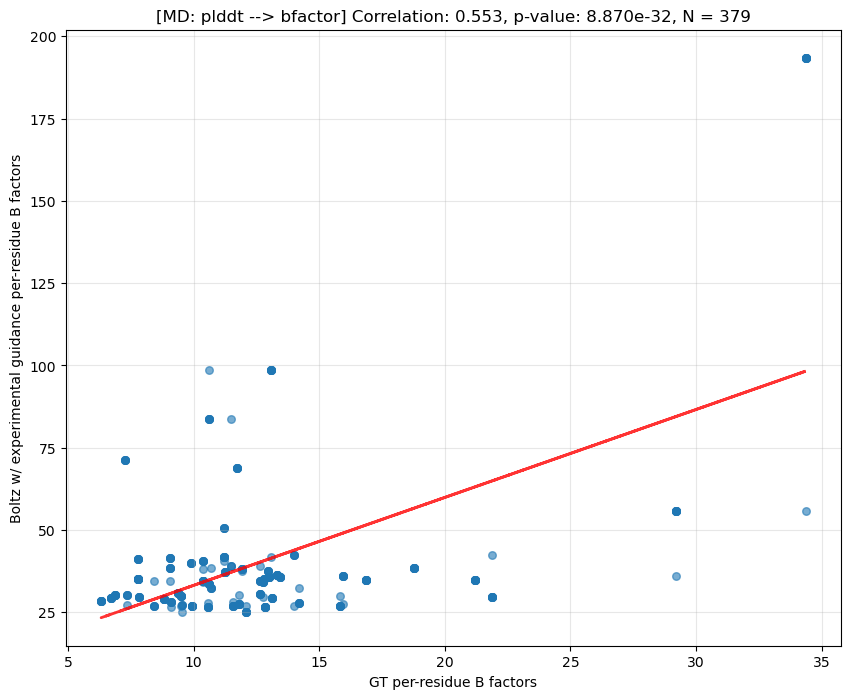

Correlation: 0.5533, p-value: 8.8696e-32


In [25]:
# plotting different b factor predictions against GT

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

csv_file_path = "atoms_biso_md_plddt2bfactor.csv"
csv_b_factors = pd.read_csv(csv_file_path, header=None).iloc[:, 0].values

# Get sfcalculator B factors
sfcalc_b_factors = residue_b_factors

# Match lengths
min_length = min(len(sfcalc_b_factors), len(csv_b_factors))
sfcalc_b_factors = sfcalc_b_factors[:min_length]
csv_b_factors = csv_b_factors[:min_length]

# Calculate correlation
correlation, p_value = stats.pearsonr(sfcalc_b_factors, csv_b_factors)

# Create plot
plt.figure(figsize=(10, 8))
plt.scatter(sfcalc_b_factors, csv_b_factors, alpha=0.6, s=30)

# Trend line
z = np.polyfit(sfcalc_b_factors, csv_b_factors, 1)
p = np.poly1d(z)
plt.plot(sfcalc_b_factors, p(sfcalc_b_factors), "r--", alpha=0.8, linewidth=2)

plt.xlabel('GT per-residue B factors')
# plt.ylabel('Boltz per-residue B factors')
plt.ylabel('Boltz w/ experimental guidance per-residue B factors')
plt.title(f'[MD: plddt --> bfactor] Correlation: {correlation:.3f}, p-value: {p_value:.3e}, N = {min_length}')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Correlation: {correlation:.4f}, p-value: {p_value:.4e}")
